# Recommendation System Project: IBM Community

In this notebook, you will be putting your recommendation skills to use on real data from the IBM Watson Studio platform. 


You may either submit your notebook through the workspace here, or you may work from your local machine and submit through the next page.  Either way assure that your code passes the project [RUBRIC](https://review.udacity.com/#!/rubrics/3325/view).  **Please save regularly.**

By following the table of contents, you will build out a number of different methods for making recommendations that can be used for different situations. 


## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)<br>
II. [Rank Based Recommendations](#Rank)<br>
III. [User-User Based Collaborative Filtering](#User-User)<br>
IV. [Content Based Recommendations](#Content-Recs)<br>
V. [Matrix Factorization](#Matrix-Fact)<br>
VI. [Extras & Concluding](#conclusions)

At the end of the notebook, you will find directions for how to submit your work.  Let's get started by importing the necessary libraries and reading in the data.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_tests as t


df = pd.read_csv(
    'data/user-item-interactions.csv', 
    dtype={'article_id': int, 'title': str, 'email': str}
)
# Show df to get an idea of the data
df.head()

,Unnamed: 0,article_id,title,email
0,0,1430,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1,1314,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,2,1429,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,3,1338,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,4,1276,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


### <a class="anchor" id="Exploratory-Data-Analysis">Part I : Exploratory Data Analysis</a>

Use the dictionary and cells below to provide some insight into the descriptive statistics of the data.

`1.` Are there any missing values? If so, provide a count of missing values. If there are missing values in `email`, assign it the same id value `"unknown_user"`.

In [65]:
# Some interactions do not have a user associated with it, assume the same user.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45993 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  45993 non-null  int64 
 1   article_id  45993 non-null  int64 
 2   title       45993 non-null  object
 3   email       45976 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.4+ MB


In [66]:
print(f"Number of Null email values is: ")

Number of Null email values is: 


In [67]:
df[df.email.isna()]

,Unnamed: 0,article_id,title,email
25131,25146,1016,why you should master r (even if it might even...,NaN
29758,30157,1393,the nurse assignment problem,NaN
29759,30158,20,working interactively with rstudio and noteboo...,NaN
29760,30159,1174,breast cancer wisconsin (diagnostic) data set,NaN
29761,30160,62,data visualization: the importance of excludin...,NaN
35264,36016,224,"using apply, sapply, lapply in r",NaN
35276,36029,961,beyond parallelize and collect,NaN
35277,36030,268,sector correlations shiny app,NaN
35278,36031,268,sector correlations shiny app,NaN
35279,36032,268,sector correlations shiny app,NaN


In [68]:
# Fill email NaNs with "unknown_user"
df['email'] = df['email'].fillna("unknown_user")

In [69]:
# Check if no more NaNs 
df[df.email.isna()]

,Unnamed: 0,article_id,title,email


`2.` What is the distribution of how many articles a user interacts with in the dataset?  Provide a visual and descriptive statistics to assist with giving a look at the number of times each user interacts with an article.

In [70]:
# What are the descriptive statistics of the number of articles a user interacts with?
user_interactions = df.groupby('email')['article_id'].count()
user_interactions.describe()

count    5149.000000
mean        8.932414
std        16.801011
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       364.000000
Name: article_id, dtype: float64

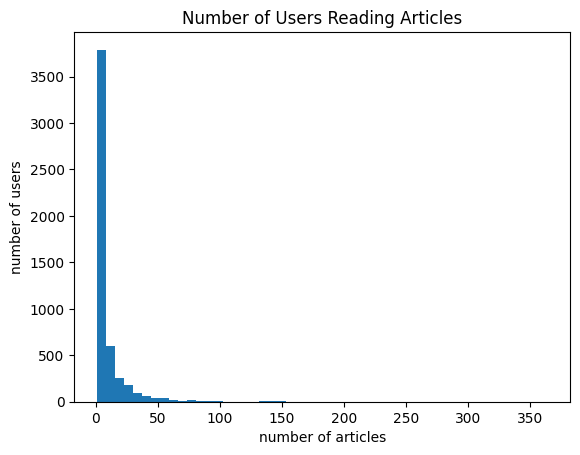

In [71]:
# Create a plot of the number of articles read by each user
import matplotlib.pyplot as plt

plt.hist(user_interactions, bins=50)
plt.xlabel('number of articles')
plt.ylabel('number of users')
plt.title('Number of Users Reading Articles')
plt.show()

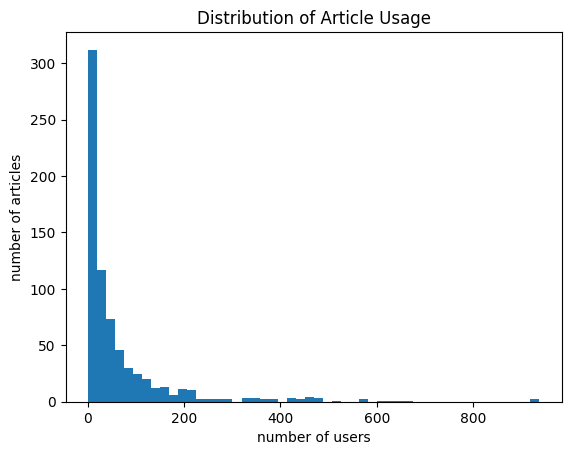

In [72]:
# Create a plot of the number of times each article was read

article_interactions = df.groupby('article_id')['email'].count()
plt.hist(article_interactions, bins=50)

plt.xlabel('number of users')
plt.ylabel('number of articles')
plt.title('Distribution of Article Usage')
plt.show()

In [73]:
# Fill in the median and maximum number of user_article interactions below

median_val = int(user_interactions.median())  # 50% of individuals interact with 3 number of articles or fewer.
max_views_by_user = int(user_interactions.max()) # The maximum number of user-article interactions by any 1 user is 364.

print("Median interactions:", median_val)
print("Max interactions by a user:", max_views_by_user)

Median interactions: 3
Max interactions by a user: 364


`3.` Use the cells below to find:

**a.** The number of unique articles that have an interaction with a user.  
**b.** The number of unique articles in the dataset (whether they have any interactions or not).<br>
**c.** The number of unique users in the dataset. (excluding null values) <br>
**d.** The number of user-article interactions in the dataset.

In [74]:
unique_articles = df['article_id'].nunique() # The number of unique articles that have at least one interaction
total_articles = df['article_id'].nunique() # The number of unique articles on the IBM platform
unique_users = df['email'].nunique() # The number of unique users
user_article_interactions = df.shape[0] # The number of user-article interactions

#Since the content dataset is not available, the total number of articles 
#is assumed to be equal to the number of unique articles present in the 
#interaction dataset.

#This limitation highlights the importance of having complete content data 
#when building recommendation systems.

#This may underestimate the total number of articles if there are articles 
#that have not received any user interactions.

print('Unique Articles', unique_articles)
print('Total Articles', total_articles)
print('Unique Users', unique_users)
print('User Article Interactions', user_article_interactions)

Unique Articles 714
Total Articles 714
Unique Users 5149
User Article Interactions 45993


`4.` Use the cells below to find the most viewed **article_id**, as well as how often it was viewed.  After talking to the company leaders, the `email_mapper` function was deemed a reasonable way to map users to ids.  There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [75]:
df['article_id'] = df['article_id'].astype(float)
article_counts = df['article_id'].value_counts()

most_viewed_article_id = article_counts.idxmax() # The most viewed article in the dataset as a string with one value following the decimal 
max_views = int(article_counts.max()) # The most viewed article in the dataset was viewed how many times?

print('Most viewed ID:', most_viewed_article_id)
print('Max Views:', max_views)


Most viewed ID: 1429.0
Max Views: 937


In [76]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper(df=df):
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

# show header
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",1
1,1,1314.0,healthcare python streaming application demo,2
2,2,1429.0,use deep learning for image classification,3
3,3,1338.0,ml optimization using cognitive assistant,4
4,4,1276.0,deploy your python model as a restful api,5


In [77]:
## If you stored all your results in the variable names above, 
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

# Test your dictionary against the solution
t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


### <a class="anchor" id="Rank">Part II: Rank-Based Recommendations</a>

In this project, we don't actually have ratings for whether a user liked an article or not.  We only know that a user has interacted with an article. In these cases, the popularity of an article can really only be based on how often an article was interacted with.

`1.` Fill in the function below to return the **n** top articles ordered with most interactions as the top. Test your function using the tests below.

In [78]:
def get_top_articles(n, df=df): 
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe)
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    """
    
    top_articles = (
        df.groupby('title')
          .size()
          .sort_values(ascending=False)
          .head(n)
          .index
          .tolist()
    )
    
    return top_articles


def get_top_article_ids(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe)
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article ids 
    """
    
    top_articles = (
        df.groupby('article_id')
          .size()
          .sort_values(ascending=False)
          .head(n)
          .index
          .astype(str)
          .tolist()
    )
    
    top_articles = df['article_id'].value_counts()
    
    return top_articles.index[:n].tolist()

In [79]:
print(get_top_articles(10))
print(get_top_article_ids(10))

['use deep learning for image classification', 'insights from new york car accident reports', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'finding optimal locations of new store using decision optimization', 'apache spark lab, part 1: basic concepts', 'analyze energy consumption in buildings', 'gosales transactions for logistic regression model']
[1429.0, 1330.0, 1431.0, 1427.0, 1364.0, 1314.0, 1293.0, 1170.0, 1162.0, 1304.0]


In [80]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Test each of your three lists from above
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


### <a class="anchor" id="User-User">Part III: User-User Based Collaborative Filtering</a>


`1.` Use the function below to reformat the **df** dataframe to be shaped with users as the rows and articles as the columns.  

* Each **user** should only appear in each **row** once.


* Each **article** should only show up in one **column**.  


* **If a user has interacted with an article, then place a 1 where the user-row meets for that article-column**.  It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.  


* **If a user has not interacted with an item, then place a zero where the user-row meets for that article-column**. 

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [81]:
# create the user-article matrix with 1's and 0's

def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns
    
    OUTPUT:
    user_item - user item matrix 
    
    Description:
    Return a matrix with user ids as rows and article ids on the columns with 1 values where a user interacted with 
    an article and a 0 otherwise
    """
    # Fill in the function here
    df_unique = df[['user_id', 'article_id']].drop_duplicates()
    
    user_item = df_unique.assign(interaction=1).pivot(
        index='user_id',
        columns='article_id',
        values='interaction'
    )
    
    user_item = user_item.fillna(fill_value).astype(int)
    
    return user_item # return the user_item matrix 

user_item = create_user_item_matrix(df)

In [82]:
## Tests: You should just need to run this cell.  Don't change the code.
assert user_item.shape[0] == 5149, "Oops!  The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714, "Oops!  The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops!  The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


`2.` Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar).  The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users. 

Use the tests to test your function.

In [83]:
# Lets use the cosine_similarity function from sklearn
from sklearn.metrics.pairwise import cosine_similarity

In [84]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    user_item_matrix = user_item.values
    user_ids = user_item.index
    
    user_idx = np.where(user_ids == user_id)[0][0]
    
    # Compute cosine similarity between all users
    similarity = cosine_similarity(user_item_matrix)
    
    # Get similarity scores for the given user
    user_similarity_scores = similarity[user_idx]
    
    # Create a list of (user_id, similarity) excluding the user themself
    similar_users = [
        (int(other_user_id), float(sim)) 
        for other_user_id, sim in zip(user_ids, user_similarity_scores) 
        if other_user_id != user_id
    ]
    
    # Sort by similarity (descending)
    similar_users.sort(key=lambda x: x[1], reverse=True)
    
    if include_similarity:
        return similar_users
    else:
        return [user for user, sim in similar_users]

In [85]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [3933, 46, 4201, 253, 824, 5034, 5041, 136, 2305, 395]
The 5 most similar users to user 3933 are: [1, 46, 4201, 253, 824]
The 3 most similar users to user 46 are: [4201, 790, 5077]


In [86]:
sim = user_item.dot(user_item.loc[1])
sim = sim.sort_values(ascending=False).drop(1)
print(sim.head(15))

user_id
3933    35
23      17
3782    17
203     15
4459    15
3870    14
131     14
4201    13
46      13
395     12
3697    12
49      12
5041    12
3910    11
3622    11
dtype: int64


`3.` Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend.  Complete the functions below to return the articles you would recommend to each user. 

In [87]:
def normalize_ids(ids):
    return set([int(float(x)) for x in ids])

def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    """
    article_ids = [str(int(float(x))) for x in article_ids]
    
    df_temp = df.copy()
    df_temp['article_id'] = df_temp['article_id'].apply(lambda x: str(int(float(x))))
    
    article_names = (
        df_temp[df_temp['article_id'].isin(article_ids)]
        .drop_duplicates('article_id')
        .set_index('article_id')
        .reindex(article_ids)['title']   # safer than .loc
        .dropna()
        .tolist()
    )
    
    return article_names # Return the article names associated with list of article ids

def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    article_ids - (list) a list of article ids to evaluate (a subset to rank).
                the dtype should match the column labels in `user_item`.
    user_item - (pandas dataframe) a binary matrix of users by articles [n_users x n_articles]:
                1's when a user has interacted with an article, 0 otherwise 
                columns are article IDs.
    
    OUTPUT:
    ranked_article_unique_counts - (list) a list of tuples [(article_id, unique_user_count)]
                     only for the provided `article_ids` with article_id and number of unique
                     users that have interacted with the article, sorted by the number of unique
                     users in descending order
    
    Description:
    For each `article_id` in the input list, count the number of unique users who
    interacted with it (column sum in the binary `user_item` matrix).
    Return the (article_id, count) pairs sorted in descending order.
    """
    article_ids = [int(float(x)) for x in article_ids]
    
    counts = []
    
    for article_id in article_ids:
        #article_str = str(article_id)  # for lookup
        
        if article_id in map(int, user_item.columns):
            count = user_item[article_id].sum()
            counts.append([article_id, int(count)])
    
    # sort by count descending
    ranked_article_unique_counts = sorted(
        counts, key=lambda x: x[1], reverse=True
    )
    
    
    return ranked_article_unique_counts


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    
    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    
    Description:
    Provides a list of the article_ids and article titles that have been seen by a user
    """
    user_row = user_item.loc[user_id]
    
    article_ids = user_row[user_row == 1].index.tolist()
    
    article_names = get_article_names(article_ids)
    
    
    return article_ids, article_names # return the ids and names


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    Users who are the same closeness are chosen arbitrarily as the 'next' user
    
    For the user where the number of recommended articles starts below m 
    and ends exceeding m, the last items are chosen arbitrarily
    
    """
    seen_articles_seen = get_user_articles(user_id)[0]
    #seen_articles = normalize_ids(seen_articles)

    
    # Step 2: Get similar users
    similar_users = find_similar_users(user_id)
    
    recs = []
    
    # Step 3: Loop through similar users
    for neighbor in similar_users:
        neighbor_articles_seen = get_user_articles(neighbor)[0]
        #neighbor_articles = normalize_ids(neighbor_articles)

        new_articles = np.setdiff1d(neighbor_articles_seen, seen_articles_seen, assume_unique=True)
        recs = np.unique(np.concatenate([new_articles, recs], axis=0))

        if len(recs) > m-1:
            break

    recs = recs[:m]
    recs.tolist()

    return recs[:m] # return your recommendations for this user_id   
  

In [88]:
# Check Results
get_article_names(user_user_recs(1, 10)) # Return 10 recommendations for user 1

['this week in data science (april 18, 2017)',
 'this week in data science (may 2, 2017)',
 'top 20 r machine learning and data science packages',
 'improving the roi of big data and analytics through leveraging new sources of data',
 'using apply, sapply, lapply in r',
 'awesome deep learning papers',
 'leverage python, scikit, and text classification for behavioral profiling',
 'challenges in deep learning',
 'do i need to learn r?',
 'how can data scientists collaborate to build better business']

In [89]:
get_ranked_article_unique_counts([1320, 232, 844])

[[1320, 123], [844, 78], [232, 62]]

In [90]:
# Test your functions here - No need to change this code - just run this cell
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_article_names([1320, 232, 844])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_user_articles(20)[0]) == set([1320, 232, 844])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set([1024, 1176, 1305, 1314, 1422, 1427])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == [1320, 123], "Oops! Your the get_ranked_article_unique_counts function doesn't work quite how we expect.\nMake sure you are using the user_item matrix to create the article counts."
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


`4.` Now we are going to improve the consistency of the **user_user_recs** function from above.  

* Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.


* Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be  what would be obtained from the **top_articles** function you wrote earlier.

In [91]:
def get_top_sorted_users(user_id, df=df, user_item=user_item):
    '''
    INPUT:
    user_id - (int)
    df - (pandas dataframe)
    user_item - (pandas dataframe)
    
    OUTPUT:
    neighbors_df - (pandas dataframe) with neighbor_id, similarity, num_interactions
    '''
    # Calculate Cosine Similarity
    # Reshape the target user vector to (1, n_features)
    user_vector = user_item.loc[user_id].values.reshape(1, -1)
    all_users_matrix = cosine_similarity(user_vector, user_item)
        
    # Create the initial DataFrame
    neighbors_df = pd.DataFrame({
        'neighbor_id': user_item.index,
        'similarity': all_users_matrix.flatten()
    })
    
    # Get total interactions for each user
    interacts_df = user_item.sum(axis=1) \
    .rename('num_interactions') \
    .reset_index() \
    .rename(columns={'user_id': 'neighbor_id'})
    
    #interacts_df = df.groupby('user_id')['article_id'].count().rename_axis('neighbor_id').reset_index(name='num_interactions')
    
    # Merge similarity with interaction counts
    neighbors_df = pd.merge(neighbors_df, interacts_df, on='neighbor_id', how='left')
    
    # Remove the user themselves from the neighbor list
    neighbors_df = neighbors_df[neighbors_df.neighbor_id != user_id]

    # Sort by similarity (descending) first, then by num_interactions (descending)
    neighbors_df = neighbors_df.sort_values(by=['similarity', 'num_interactions'], 
                                            ascending=False)
    
    # Reset index for a clean dataframe return
    neighbors_df = neighbors_df.reset_index(drop=True)
    return neighbors_df

def user_user_recs_part2(user_id, m=10):
    '''
    INPUT:
    user_id - (int)
    m - (int) number of recommendations
    
    OUTPUT:
    recs - (list) top m article ids
    rec_names - (list) top m article names
    '''
    # Get user's seen history
    seen_ids, _ = get_user_articles(user_id)
    
    # Get neighbors sorted by cosine similarity
    neighbors_df = get_top_sorted_users(user_id)
    
    # Global article popularity for tie-breaking article selection
    article_interactions = df.groupby('article_id').count()['user_id']
    
    recs = []
    
    for neighbor in neighbors_df['neighbor_id']:
        neighbor_ids, _ = get_user_articles(neighbor)
        
        # Articles neighbor has seen but user hasn't
        new_potential_recs = np.setdiff1d(neighbor_ids, seen_ids, assume_unique=True)
        
        # Sort these specific articles by global popularity
        # This fulfills the "Choose articles with the most total interactions" requirement
        sorted_new_recs = article_interactions.loc[new_potential_recs].sort_values(ascending=False).index.tolist()
        
        for art_id in sorted_new_recs:
            if art_id not in recs:
                recs.append(str(art_id))
            
            if len(recs) >= m:
                break
        
        if len(recs) >= m:
            break
            
    rec_names = get_article_names(recs)
    
    return recs, rec_names


In [92]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
['1293.0', '1162.0', '1185.0', '1165.0', '1293.0', '1185.0', '1165.0', '254.0', '1271.0', '1328.0']

The top 10 recommendations for user 20 are the following article names:
['finding optimal locations of new store using decision optimization', 'analyze energy consumption in buildings', 'classify tumors with machine learning', 'analyze precipitation data', 'finding optimal locations of new store using decision optimization', 'classify tumors with machine learning', 'analyze precipitation data', 'apple, ibm add machine learning to partnership with watson-core ml coupling', 'customer demographics and sales', 'income (2015): united states demographic measures']


`5.` Use your functions from above to correctly fill in the solutions to the dictionary below.  Then test your dictionary against the solution.  Provide the code you need to answer each following the comments below.

In [93]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

   neighbor_id  similarity  num_interactions
0         3933    0.986013                35
   neighbor_id  similarity  num_interactions
0         5083    0.730297                 5
1         1552    0.577350                 2
2         1890    0.577350                 2
3         1372    0.471405                 3
4         2941    0.433013                 8
5         3586    0.408248                 4
6          331    0.408248                 1
7          348    0.408248                 1
8          378    0.408248                 1
9          496    0.408248                 1
   neighbor_id  similarity  num_interactions
0         3870    0.986667                75
1          203    0.388909                96
2         4459    0.388909                96
3         3782    0.387585               135
4           40    0.384308                52
5         4932    0.384308                52
6           23    0.377647               135
7          242    0.375823                59
8         

In [94]:
### Tests with a dictionary of results
user1_most_sim = get_top_sorted_users(1).iloc[0]['neighbor_id'] # Find the user that is most similar to user 1 
user2_6th_sim = get_top_sorted_users(2).iloc[5]['neighbor_id'] # Find the 6th most similar user to user 2
user131_10th_sim = get_top_sorted_users(131).iloc[9]['neighbor_id'] # Find the 10th most similar user to user 131

In [95]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim, 
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}

t.sol_5_test(sol_5_dict)

This all looks good!  Nice job!


`6.` If we were given a new user, which of the above functions would you be able to use to make recommendations?  Explain.  Can you think of a better way we might make recommendations?  Use the cell below to explain a better method for new users.

**Your response here**
For a new user, we cannot use collaborative filtering methods like user_user_recs because these approaches rely on past user interactions to find similar users. Since a new user has no interaction history, there is no basis to compute similarity or generate recommendations.

Instead, we can use rank-based recommendations such as get_top_articles or get_top_article_ids, which recommend the most popular articles across all users. These methods do not depend on individual user history and therefore work well for new users.

A better approach for new users would be to use content-based recommendations or hybrid methods. For example, we could recommend articles based on:

article categories or topics
keywords or text similarity
trending or recent content

Additionally, we could ask the user to select a few topics of interest during onboarding, and then recommend articles similar to those topics. This would allow us to personalize recommendations even without historical interaction data.

`7.` Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below.  You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [96]:
# What would your recommendations be for this new user 0?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to 

new_user_recs = get_top_article_ids(10)
set(new_user_recs)

{1162.0,
 1170.0,
 1293.0,
 1304.0,
 1314.0,
 1330.0,
 1364.0,
 1427.0,
 1429.0,
 1431.0}

In [97]:
assert set(new_user_recs) == {1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330}, "Oops!  It makes sense that in this case we would want to recommend the most popular articles, because we don't know anything about these users."

print("That's right!  Nice job!")

That's right!  Nice job!


### <a class="anchor" id="Content-Recs">Part IV: Content Based Recommendations</a>

Another method we might use to make recommendations is to recommend similar articles that are possibly related. One way we can find article relationships is by clustering text about those articles.  Let's consider content to be the article **title**, as it is the only text we have available. One point to highlight, there isn't one way to create a content based recommendation, especially considering that text information can be processed in many ways.  

`1.` Use the function bodies below to create a content based recommender function `make_content_recs`. We'll use TF-IDF to create a matrix based off article titles, and use this matrix to create clusters of related articles. You can use this function to make recommendations of new articles.

In [98]:
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",1
1,1,1314.0,healthcare python streaming application demo,2
2,2,1429.0,use deep learning for image classification,3
3,3,1338.0,ml optimization using cognitive assistant,4
4,4,1276.0,deploy your python model as a restful api,5


In [99]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [100]:
# unique articles
df_unique_articles = df.drop_duplicates(subset='article_id')

In [101]:
# Create a vectorizer using TfidfVectorizer and fit it to the article titles
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)
print("Running TF-IDF")
X_tfidf = vectorizer.fit_transform(df_unique_articles['title'])

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)
explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Running TF-IDF


n_samples: 714, n_features: 125
Explained variance of the SVD step: 76.0%


Text(0.5, 0, 'Number of clusters')

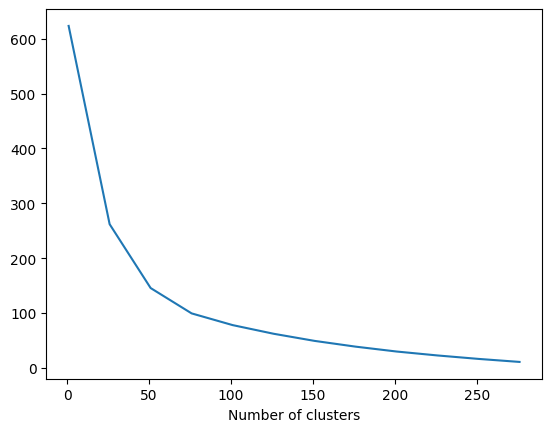

In [102]:
# Let's map the inertia for different number of clusters to find the optimal number of clusters
# We'll plot it to see the elbow
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42
for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    # inertia is the sum of squared distances to the closest cluster center
    inertia.append(kmeans.inertia_)
plt.plot(range(1, clusters, step), inertia)
plt.xlabel('Number of clusters')

There appears to be an elbow about 50, so we'll use 50 clusters.

In [103]:
n_clusters = 50  

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
).fit(X_lsa)

In [104]:
# create a new column `title_cluster` and assign it the kmeans cluster labels
# First we need to map the labels to df_unique_articles article ids and then apply those to df
article_cluster_map = dict(
    zip(df_unique_articles['article_id'], kmeans.labels_)
)
df['title_cluster'] = df['article_id'].map(article_cluster_map)

In [105]:
# Let's check the number of articles in each cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

array([[ 0, 12],
       [ 1, 28],
       [ 2, 23],
       [ 3, 62],
       [ 4, 12],
       [ 5, 27],
       [ 6, 20],
       [ 7, 13],
       [ 8, 29],
       [ 9, 44],
       [10, 19],
       [11, 20],
       [12, 29],
       [13,  2],
       [14,  8],
       [15, 21],
       [16, 28],
       [17, 10],
       [18,  9],
       [19,  7],
       [20, 17],
       [21,  8],
       [22,  6],
       [23,  7],
       [24,  8],
       [25, 11],
       [26, 14],
       [27, 17],
       [28, 21],
       [29,  5],
       [30,  6],
       [31,  9],
       [32, 15],
       [33,  7],
       [34, 11],
       [35,  5],
       [36,  8],
       [37,  8],
       [38,  9],
       [39, 11],
       [40,  8],
       [41,  8],
       [42,  8],
       [43,  5],
       [44, 10],
       [45, 12],
       [46,  6],
       [47, 11],
       [48, 11],
       [49,  9]])

In [106]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id 
    df - (pandas dataframe)
    
    OUTPUT:
    article_ids - (list) a list of article ids in the same title cluster
    """

    title_cluster = df[df['article_id'] == article_id]['title_cluster'].iloc[0]

    articles_in_cluster = df[df['title_cluster'] == title_cluster]['article_id'].unique().tolist()

    if article_id in articles_in_cluster:
        articles_in_cluster.remove(article_id)

    return articles_in_cluster

In [107]:
def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n - (int) number of recommendations
    df - (pandas dataframe)
    
    OUTPUT:
    n_ranked_similar_articles - (list) article ids
    n_ranked_article_names - (list) article names
    """

    similar_articles = get_similar_articles(article_id, df)

    if len(similar_articles) == 0:
        return [], []

    ranked_ids = get_ranked_article_unique_counts(similar_articles)[0]

    n_ranked_similar_articles = ranked_ids[:n]

    n_ranked_article_names = get_article_names(n_ranked_similar_articles)

    return n_ranked_similar_articles, n_ranked_article_names

In [108]:
# Test out your content recommendations given artice_id 25
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

[1025, 147]
['data tidying in data science experience']


In [109]:
assert len({1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}.intersection(set(rec_article_ids))) > 0, "Oops! Your the make_content_recs function doesn't work quite how we expect."

`2.` Now that you have put together your content-based recommendation system, use the cell below to write a summary explaining how your content based recommender works.  Do you see any possible improvements that could be made to your function? What other text data would be useful to help make better recommendations besides the article title?

**Write an explanation of your content based recommendation system here.**
Summary of the Content-Based Recommender

The content-based recommendation system groups articles based on the similarity of their titles and recommends articles from the same group.

First, article titles are converted into numerical representations using TF-IDF (Term Frequency–Inverse Document Frequency). This captures the importance of words in each title relative to the entire dataset. To reduce dimensionality and capture latent semantic relationships, Truncated SVD (Latent Semantic Analysis) is applied, transforming the TF-IDF matrix into a lower-dimensional representation.

Next, KMeans clustering is used on this reduced feature space to group similar articles into clusters. Each article is assigned a cluster label, which represents a topic or theme inferred from its title.

To generate recommendations for a given article:

The cluster of the input article is identified.
All other articles within the same cluster are retrieved.
These articles are ranked based on popularity (number of user interactions).
The top n articles are returned as recommendations.

This approach ensures that recommended articles are both topically similar and popular among users.

🔍 Possible Improvements

While the current system works, there are several areas for improvement:

1. Replace Clustering with Similarity-Based Ranking

Instead of grouping articles into clusters, we could compute cosine similarity between article vectors and directly recommend the most similar articles.
👉 This provides more fine-grained and accurate recommendations compared to cluster-based grouping.

2. Better Feature Representation
Titles are often short and may not fully capture article meaning.
TF-IDF ignores word order and context.

👉 Improvements:

Use word embeddings (Word2Vec, GloVe)
Use transformer-based embeddings (e.g., BERT)
3. Improve Ranking Strategy

Currently, ranking is based only on popularity.

👉 Better approach:

Combine:
similarity score
popularity
recency (new articles)
4. Dynamic / Adaptive Clustering
Fixed k=50 may not be optimal
Different datasets require different cluster sizes

👉 Use:

silhouette score
hierarchical clustering

### <a class="anchor" id="Matrix-Fact">Part V: Matrix Factorization</a>

In this part of the notebook, you will build use matrix factorization to make article recommendations to users.

`1.` You should have already created a **user_item** matrix above in **question 1** of **Part III** above.  This first question here will just require that you run the cells to get things set up for the rest of **Part V** of the notebook. 

In [110]:
# quick look at the matrix
user_item.head()

article_id,0.0,2.0,4.0,8.0,9.0,12.0,14.0,15.0,16.0,18.0,...,1434.0,1435.0,1436.0,1437.0,1439.0,1440.0,1441.0,1442.0,1443.0,1444.0
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


`2.` In this situation, you can use Singular Value Decomposition from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) on the user-item matrix.  Use the cell to perform SVD.

In [111]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score
# Using the full number of components which equals the number of columns
svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_ 
print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

u (5149, 714)
s (714,)
vt (714, 714)


The traditional SVD can be applied here because the user_item matrix contains no missing values. In this project, every cell is filled with either a 1 (interaction) or a 0 (no interaction). If the matrix had missing values (NaNs) representing unknown preferences—as is common in many rating-based datasets—Standard SVD would fail, and we would instead need to use iterative approaches like FunkSVD. Identifying this "binary and complete" nature of the data is essential for demonstrated project mastery.

`3.` Now for the tricky part, how do we choose the number of latent features to use?  Running the below cell, you can see that as the number of latent features increases, we obtain better metrics when making predictions for the 1 and 0 values in the user-item matrix.  Run the cell below to get an idea of how our metrics improve as we increase the number of latent features.

Text(0.5, 1.0, 'Metrics vs. Number of Latent Features')

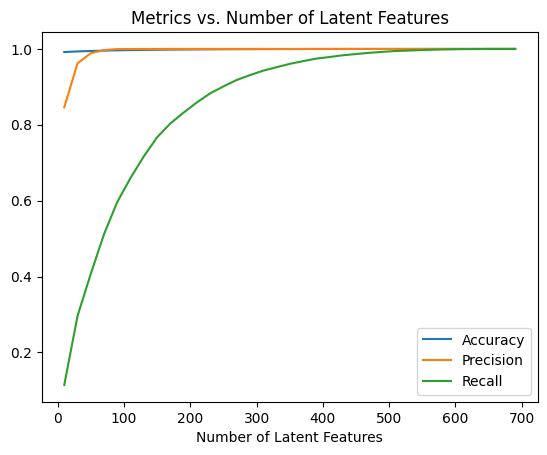

In [112]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # restructure with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]
    
    # take dot product
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    # make sure the values are between 0 and 1
    user_item_est = np.clip(user_item_est, 0, 1)
    
    # total errors and keep track of them
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])
    
    
plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')

`4.` From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations. Given the plot above, what would you pick for the number of latent features and why?

**Provide your response here.**
Based on the plot, I would choose approximately 50 latent features.

From the curve, we can observe that the model performance improves significantly as we increase the number of latent features up to around 50. After this point, the improvement becomes much smaller, indicating diminishing returns. This suggests that most of the important structure in the user-item interaction data is captured within the first 50 features.

Choosing fewer than 50 features would likely result in underfitting, where the model does not capture enough information about user preferences and article relationships. On the other hand, using significantly more than 50 features increases model complexity without substantial gains, and may introduce noise or overfitting.

Therefore, selecting around 50 latent features provides a good balance between model performance and complexity, while efficiently capturing the underlying patterns needed for making recommendations.

`5.` Using 200 latent features and the values of U, S, and V transpose we calculated above, create an article id recommendation function that finds similar article ids to the one provide.

Create a list of 10 recommendations that are similar to article with id 4.  The function should provide these recommendations by finding articles that have the most similar latent features as the provided article.

In [113]:
from sklearn.metrics.pairwise import cosine_similarity

def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    Returns similar articles using SVD latent features
    """

    # 🔹 Step 1: Get article index from user_item columns
    article_ids = list(user_item.columns)
    
    if article_id not in article_ids:
        return []

    article_idx = article_ids.index(article_id)

    # 🔹 Step 2: Compute cosine similarity between articles
    # vt.T shape → (num_articles, k)
    cos_sim = cosine_similarity(vt.T)

    # 🔹 Step 3: Get similarity scores for the given article
    sim_scores = list(enumerate(cos_sim[article_idx]))

    # 🔹 Step 4: Sort by similarity (descending)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # 🔹 Step 5: Remove the article itself (first one)
    sim_scores = sim_scores[1:]

    # 🔹 Step 6: Get ordered article_ids
    most_similar_items = [article_ids[i] for i, _ in sim_scores]

    if include_similarity:
        return [[article_ids[i], score] for i, score in sim_scores]

    return most_similar_items

In [114]:
# Create a vt_new matrix with 200 latent features
k = 200
vt_new = v[:k, :]

In [115]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

Current article: analyze ny restaurant data using spark in dsx


In [116]:
# What are the top 10 most similar articles to article_id 4?
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
rec_articles

[1199.0, 1068.0, 486.0, 1202.0, 176.0, 1120.0, 244.0, 793.0, 58.0, 132.0]

In [117]:
# What are the top 10 most similar articles to article_id 4?
get_article_names(rec_articles, df=df)

['country statistics: crude oil - exports',
 'airbnb data for analytics: athens reviews',
 'use spark r to load and analyze data',
 'country statistics: crude oil - proved reserves',
 'top analytics tools in 2016',
 'airbnb data for analytics: paris calendar',
 'notebooks: a power tool for data scientists',
 '10 powerful features on watson data platform, no coding necessary',
 'advancements in the spark community',
 'collecting data science cheat sheets']

In [118]:
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}, "Oops! Your the get_svd_similar_article_ids function doesn't work quite how we expect."
print("That's right!  Great job!")

That's right!  Great job!


`6.` Use the cell below to comment on the results you found in the previous question. Given the circumstances of your results, discuss what you might do to determine if the recommendations you make above are an improvement to how users currently find articles, either by Sections 2, 3, or 4? Add any tradeoffs between each of the methods, and how you could leverage each type for different situations including new users with no history, recently new users with little history, and users with a lot of history. 

**Your response here.**
The results above show that matrix factorization (SVD) is able to capture latent relationships between users and articles, but evaluating performance using reconstruction error alone does not necessarily guarantee better recommendation quality. Since recommendation systems are ultimately judged by how relevant and useful the suggestions are to users, additional evaluation methods are required.

To determine whether these recommendations are an improvement over previous approaches (Sections 2: rank-based, 3: user-user collaborative filtering, and 4: content-based), I would evaluate them using user-centric metrics such as precision@k, recall@k, or click-through rate (CTR) on a validation set. A/B testing in a real-world scenario would provide the most reliable evidence by comparing how users engage with different recommendation strategies.

🔄 Tradeoffs Between Methods
1. Rank-Based Recommendations
Pros: Simple, no user data required, works well for new users
Cons: Not personalized, recommends only popular articles
2. User-User Collaborative Filtering
Pros: Personalized based on similar users
Cons: Suffers from cold-start problem, sparse data issues
3. Content-Based Filtering
Pros: Works for new or less active users, interpretable
Cons: Limited by quality of content features (e.g., only titles), less diverse recommendations
4. Matrix Factorization (SVD)
Pros: Captures latent patterns, scalable, often more accurate
Cons: Harder to interpret, requires sufficient interaction data, still struggles with cold start
 Strategy for Different User Types
🔹 New Users (No History)
Best approach: Rank-based or content-based
Reason: No interaction data available
Example: Recommend most popular or trending articles
🔹 Users with Little History
Best approach: Content-based + light collaborative filtering
Reason: Some signals exist but not enough for strong CF
Strategy: Recommend articles similar to what they have interacted with
🔹 Users with Rich History
Best approach: Collaborative filtering or SVD
Reason: Enough data to learn meaningful patterns
Strategy: Use latent features for highly personalized recommendations
💡 Final Insight

No single method is sufficient for all scenarios. A hybrid recommendation system that combines:

popularity (for robustness),
content similarity (for cold start),
and collaborative filtering/SVD (for personalization)

would provide the best overall performance across different user segments and usage scenarios.

<a id='conclusions'></a>
### Extras
Using your workbook, you could now save your recommendations for each user, develop a class to make new predictions and update your results, and make a flask app to deploy your results.  These tasks are beyond what is required for this project.  However, from what you learned in the lessons, you certainly capable of taking these tasks on to improve upon your work here!


## Conclusion

> Congratulations!  You have reached the end of the Recommendation Systems project! 

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the [rubric](https://review.udacity.com/#!/rubrics/2322/view). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.


## Directions to Submit

> Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should get a return code of 0, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations! 

In [119]:
from subprocess import call
call(['python', '-m', 'nbconvert', '--to', 'html', 'Recommendations_with_IBM.ipynb'])

0